# Full-state reach, expected finals, coverage & pair-difference analysis

Everything below is over the full `GameState` (`filled_mask, upper_total, lower_total, num_yahtzees`) under **optimal play**, composed from the already-computed turn kernels + state values (`math/state_reach_coverage.py`). No new game math.

Run the setup cell first (the forward pass takes a few minutes), then explore. Change the `lvl = ...` in a cell to look at a different level.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')                 # run from math/ so the module's data/ paths resolve
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import state_reach_coverage as src

per_level = src.forward_reach(verbose=True)   # heavy: forward pass over the full-state DAG
total = sum(len(d['reach']) for d in per_level)
print()
print(f'{total:,} states reached by optimal play (reach sums to 1 per level above)')

  level  0:           1 states, reach_sum=1.000000000
  level  1:          32 states, reach_sum=1.000000000
  level  2:         653 states, reach_sum=1.000000000
  level  3:       8,059 states, reach_sum=1.000000000
  level  4:      60,524 states, reach_sum=1.000000000
  level  5:     304,532 states, reach_sum=1.000000000
  level  6:   1,072,153 states, reach_sum=1.000000000
  level  7:   2,635,473 states, reach_sum=1.000000000
  level  8:   4,494,436 states, reach_sum=1.000000000
  level  9:   5,379,671 states, reach_sum=1.000000000
  level 10:   4,534,281 states, reach_sum=1.000000000
  level 11:   2,582,786 states, reach_sum=1.000000000
  level 12:     935,892 states, reach_sum=1.000000000
  level 13:     180,752 states, reach_sum=1.000000000

22,189,245 states reached by optimal play (reach sums to 1 per level above)


## Coverage — min #states per level to cover each probability threshold

The `TOTAL` row sums the per-level counts; its `n_states` is every state optimal play ever reaches (≈ 21% of the ~105.5M all-play enumeration).

In [2]:
tbl = src.coverage_table(per_level)
rows = []
for lvl in range(14):
    r = tbl[lvl]
    rows.append(dict(level=lvl, n_states=r['n_states'], **{f'{t*100:g}%': r[t] for t in src.THRESHOLDS}))
t = tbl['total']
rows.append(dict(level='TOTAL', n_states=t['n_states'], **{f'{x*100:g}%': t[x] for x in src.THRESHOLDS}))
pd.DataFrame(rows).set_index('level')

,n_states,50%,90%,99%,99.9%,99.99%
level,,,,,,
0,1,1,1,1,1,1
1,32,7,21,29,32,32
2,653,62,253,480,594,630
3,8059,384,2222,5133,6725,7447
4,60524,1713,13566,33317,45533,52744
5,304532,6235,54189,135716,198323,243007
6,1072153,17037,143239,380377,598281,766009
7,2635473,31820,267744,757168,1240568,1650556
8,4494436,40265,356742,1044772,1757392,2415355


## Expected final points per state

`expected_final = locked + V(reduced projection)`. Sanity check: level 0 (the empty card) should be `V(empty) ≈ 254.6`.

In [3]:
for lvl in range(14):
    d = per_level[lvl]
    ef, w = d['expected_final'], d['reach']
    print(f'level {lvl:2d}: min {ef.min():7.1f}   reach-mean {np.average(ef, weights=w):7.1f}   max {ef.max():7.1f}')

level  0: min   254.6   reach-mean   254.6   max   254.6
level  1: min   239.0   reach-mean   254.6   max   320.8
level  2: min   221.1   reach-mean   254.6   max   442.9
level  3: min   200.9   reach-mean   254.6   max   550.0
level  4: min   182.4   reach-mean   254.6   max   657.6
level  5: min   165.6   reach-mean   254.6   max   764.6
level  6: min   149.2   reach-mean   254.6   max   867.0
level  7: min   132.8   reach-mean   254.6   max   968.7
level  8: min   113.7   reach-mean   254.6   max  1070.4
level  9: min    94.9   reach-mean   254.6   max  1171.9
level 10: min    72.5   reach-mean   254.6   max  1272.4
level 11: min    50.7   reach-mean   254.6   max  1374.1
level 12: min    30.5   reach-mean   254.6   max  1475.8
level 13: min    12.0   reach-mean   254.6   max  1575.0


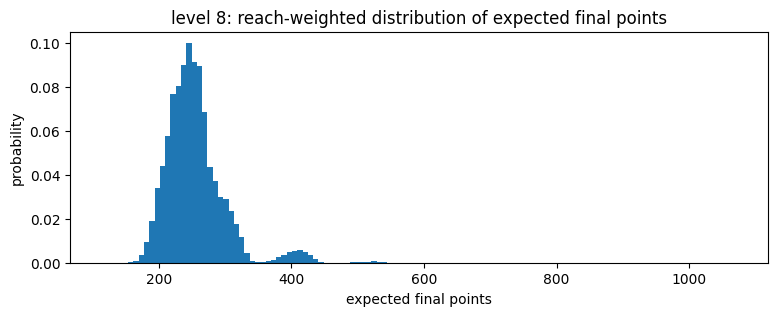

In [4]:
lvl = 8
d = per_level[lvl]
plt.figure(figsize=(9, 3))
plt.hist(d['expected_final'], bins=120, weights=d['reach'])
plt.title(f'level {lvl}: reach-weighted distribution of expected final points')
plt.xlabel('expected final points'); plt.ylabel('probability'); plt.show()

## Expected-final gap distribution (two independent optimal games)

Per level, the **probability** that two states drawn *independently* from the reach distribution have **rounded** expected finals differing by exactly `n` (absolute). `P` sums to 1 per level; `P[0]` is the chance two independent optimal games tie on rounded expected final.

In [ ]:
dd = src.diff_distribution(per_level)
for lvl in range(14):
    P = dd[lvl]
    span = int(np.nonzero(P > 1e-12)[0][-1]) if (P > 1e-12).any() else 0
    mean = float((np.arange(len(P)) * P).sum())
    print(f'level {lvl:2d}: P(|d|=0)={P[0]:.4f}   mean|d|={mean:6.2f}   max|d|={span:4d}   (sum={P.sum():.4f})')

In [ ]:
lvl = 8                          # change to inspect another level
P = dd[lvl]
plt.figure(figsize=(9, 3))
plt.plot(np.arange(len(P)), P)
plt.title(f'level {lvl}: gap distribution  P(|diff of rounded expected final| = n)')
plt.xlabel('n = |difference|'); plt.ylabel('probability'); plt.show()

# the full n -> probability array (index n) is dd[lvl]; it sums to 1. e.g.:
print('P(|diff| == 5):', f'{dd[lvl][5]:.5f}')
print('mean |diff|:   ', f'{(np.arange(len(P)) * P).sum():.2f}')

## Explore individual states

The 12 most-reached states at a chosen level, with their reach probability and expected final. `per_level[lvl]` has aligned arrays `mask, upper, lower, num_yahtzees, reach, expected_final` — slice/sort them however you like.

In [7]:
lvl = 9
d = per_level[lvl]
order = np.argsort(d['reach'])[::-1][:12]
pd.DataFrame(dict(
    mask=[format(int(m), '013b') for m in d['mask'][order]],
    upper=d['upper'][order], lower=d['lower'][order], num_y=d['num_yahtzees'][order],
    reach=d['reach'][order], exp_final=d['expected_final'][order].round(1),
))

,mask,upper,lower,num_y,reach,exp_final
0,0011100111111,63,95,0,0.001197,256.4
1,0011100111111,64,95,0,0.001057,257.4
2,0011100111111,65,95,0,0.000918,258.4
3,0011100111111,66,95,0,0.000834,259.4
4,0011100111111,67,95,0,0.000772,260.4
5,0011100111111,68,95,0,0.000709,261.4
6,0011100111111,69,95,0,0.000642,262.4
7,0011100111111,70,95,0,0.000516,263.4
8,0101100111111,63,76,0,0.000418,229.6
9,0011100111111,71,95,0,0.000389,264.4
